### Imports

In [8]:
import pandas as pd
import numpy as np
import sys
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append("..")

In [9]:
from src.data.load_data import load_tables
from src.data.validation import (
    null_report,
    duplicates_report,
    validate_tw,
    compare_neighborhoods,
    detect_outliers_iqr,
    validate_weather_ranges,
    temporal_coverage
)

sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.max_columns', None)

### Load Data

In [10]:
accidents, weather, raw = load_tables()

print(f'accidents  : {accidents.shape}')
print(f'weather     : {weather.shape}')
print(f'raw         : {raw.shape}')

accidents  : (120587, 8)
weather     : (7991780, 15)
raw         : (125122, 22)


### Temporal Coberage

In [11]:
for name, df in [('accidents', accidents), ('weather', weather), ('raw', raw)]:
    temporal_coverage(df, name)

[accidents] 2017-01-01 00:00:00 → 2019-12-31 23:00:00 | 1095 days | 22897 unique hours
[weather] 2017-01-01 00:00:00 → 2019-12-31 23:00:00 | 1095 days | 26260 unique hours
[raw] 2017-01-01 00:00:00 → 2019-12-31 23:00:00 | 1095 days | 22897 unique hours


### TW Format Validation

In [12]:
for name, df in [('accidents', accidents), ('weather', weather), ('raw_accidents', raw)]:
    problemas = validate_tw(df, name)
    if len(problemas) > 0:
        display(problemas.head())

[accidents] Rows with TW not truncated to the hour: 0
[weather] Rows with TW not truncated to the hour: 0
[raw_accidents] Rows with TW not truncated to the hour: 0


### Duplicates

In [13]:
duplicates_report(accidents, 'accidents', subset=['TW', 'BARRIO'])
duplicates_report(weather,   'weather',      subset=['TW', 'BARRIO'])
duplicates_report(raw,       'raw_accidents', subset=['RADICADO'])

[accidents] Total duplicates: 0
[accidents] Duplicates by key ['TW', 'BARRIO']: 0
[weather] Total duplicates: 0
[weather] Duplicates by key ['TW', 'BARRIO']: 0
[raw_accidents] Total duplicates: 0
[raw_accidents] Duplicates by key ['RADICADO']: 21


{'table': 'raw_accidents',
 'total_duplicates': np.int64(0),
 'key_duplicates': np.int64(21)}

### Null Values

In [14]:
nulos = pd.concat([
    null_report(accidents, 'accidents'),
    null_report(weather,   'weather'),
    null_report(raw,       'raw_accidents'),
])

display(nulos.sort_values('pct (%)', ascending=False))

,table,column,missing_values,pct (%)
2,raw_accidents,MES_NOMBRE,82740,66.13
9,weather,windBearing,1032513,12.92
0,weather,summary,548641,6.87
1,weather,icon,548641,6.87
2,weather,precipIntensity,547401,6.85
3,weather,precipProbability,547401,6.85
8,weather,windSpeed,32793,0.41
1,raw_accidents,DISENO,429,0.34
10,weather,cloudCover,7950,0.10
11,weather,uvIndex,4280,0.05


### Neighborhood Consistency

In [17]:
results = compare_neighborhoods(accidents, weather, raw)

print('\nNeighborhoods in accidents but NOT in weather:')
print(sorted(results['only_in_accidents'])[:20])

print('\nNeighborhoods in weather but NOT in accidents:')
print(sorted(results['only_in_weather'])[:20])

Common neighborhoods accidents↔weather: 319
Neighborhoods only in accidents: 3
Neighborhoods only in weather: 0

Neighborhoods in accidents but NOT in weather:
['ELASTILLERO', 'SUBURBANOAGUASFRIAS', 'YARUMALITO']

Neighborhoods in weather but NOT in accidents:
[]


### Valid Ranges - Climatic Variables

In [19]:
validate_weather_ranges = validate_weather_ranges(weather)
display(validate_weather_ranges)

,column,expected_min,expected_max,real_min,real_max,out_of_range
0,temperature,-10,50.0,4.510,35.9900,0
1,apparentTemperature,-15,55.0,4.510,38.0600,0
2,humidity,0,1.0,0.170,1.0000,0
3,precipProbability,0,1.0,0.000,1.0000,0
4,precipIntensity,0,NaN,0.000,20.8236,0
5,windSpeed,0,NaN,0.000,15.2600,0
6,cloudCover,0,1.0,0.000,1.0000,0
7,uvIndex,0,20.0,0.000,14.0000,0
8,visibility,0,20.0,0.099,16.0930,0


### Outliers (IQR) - Numerical Variables

In [20]:
weather_cols = ['temperature','apparentTemperature','humidity',
              'precipIntensity','precipProbability','windSpeed',
              'cloudCover','uvIndex','visibility']

outliers = detect_outliers_iqr(weather, weather_cols)
display(outliers.sort_values('n_outliers', ascending=False))

,column,q1,q3,lower_limit,upper_limit,n_outliers,pct (%)
3,precipIntensity,0.000,0.6058,-0.9087,1.5145,775606,10.42
5,windSpeed,0.810,2.0900,-1.1100,4.0100,426405,5.36
4,precipProbability,0.000,0.2600,-0.3900,0.6500,327735,4.40
8,visibility,10.003,15.0200,2.4775,22.5455,54931,0.69
2,humidity,0.640,0.8500,0.3250,1.1650,37767,0.47
7,uvIndex,0.000,4.0000,-6.0000,10.0000,24024,0.30
1,apparentTemperature,16.890,22.6000,8.3250,31.1650,1170,0.01
0,temperature,16.830,22.5200,8.2950,31.0550,912,0.01
6,cloudCover,0.520,0.9000,-0.0500,1.4700,0,0.00


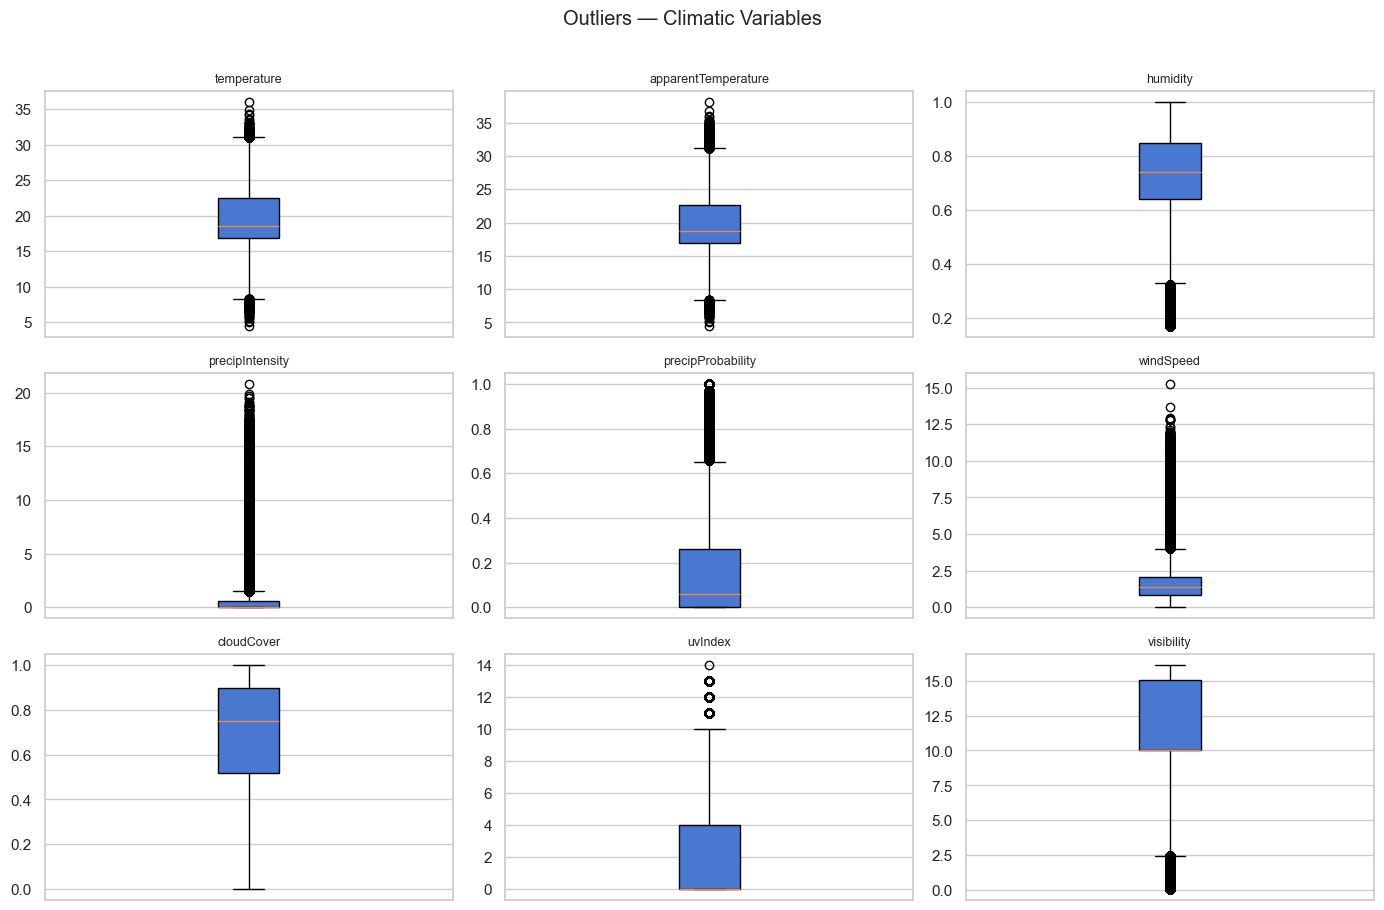

In [21]:
fig, axes = plt.subplots(3, 3, figsize=(14, 9))
axes = axes.flatten()
for i, col in enumerate(weather_cols):
    if col in weather.columns:
        axes[i].boxplot(weather[col].dropna(), vert=True, patch_artist=True)
        axes[i].set_title(col, fontsize=9)
        axes[i].set_xticks([])
plt.suptitle('Outliers — Climatic Variables', y=1.01)
plt.tight_layout()
plt.show()